#  Web Scraping Project – Books to Scrape

## Project Overview

This project demonstrates the complete web scraping workflow using **Python**, **Requests**, **BeautifulSoup**, and **Pandas**.

The objective was to extract book information from the **Books to Scrape** website, clean the collected data, perform basic analysis, and export the final dataset as a CSV file.

---

## Website

**Source:** https://books.toscrape.com/

---

## Project Objectives

* Extract book information from multiple pages.
* Scrape all available books from the website.
* Store the extracted data in a structured format.
* Clean and preprocess the collected data.
* Perform basic exploratory data analysis.
* Export the final dataset as a CSV file.

---

## Technologies Used

* Python
* Requests
* BeautifulSoup (bs4)
* Pandas
* Matplotlib

---

## Data Extracted

The following fields were collected for each book:

* Book Title
* Price
* Rating
* Availability
* Book URL

---

## Project Workflow

### 1. Data Collection

* Sent HTTP requests using the Requests library.
* Parsed HTML pages using BeautifulSoup.
* Extracted the required book information.
* Implemented pagination to scrape all available pages.

---

### 2. Data Cleaning

* Removed the currency symbol from the Price column.
* Converted Price into numeric (float) format.
* Converted Rating values from text (One–Five) to numeric values (1–5).
* Created a clean Pandas DataFrame for analysis.

---

### 3. Data Analysis

Performed basic analysis including:

* Total number of books
* Highest-priced books
* Lowest-priced books
* Rating distribution
* Average price by rating
* Maximum price by rating

---

## Final Output

* Successfully scraped **1,000 books**
* Created a clean dataset
* Exported the dataset to **books_data.csv**

---

## Learning Outcomes

This project demonstrates practical experience with:

* Web Scraping
* HTML Parsing
* Pagination
* Data Cleaning
* Data Analysis using Pandas
* CSV Export
* Python Automation

---

## Conclusion

The project successfully collected, cleaned, analyzed, and exported data from a multi-page website. It provides a complete end-to-end example of a basic web scraping and data analysis workflow using Python.


In [ ]:
from inspect import formatargvalues
import requests
from bs4 import BeautifulSoup
import pandas as pd


url = "https://books.toscrape.com/catalogue/page-1.html"
response = requests.get(url)
response = requests.get(url)
soup = BeautifulSoup(response.text, "lxml")


"""Extracting the Books Name"""
books = soup.find_all("article")
first_book = books[0]
title_tag = first_book.find("h3")
link_tag = title_tag.find("a")
title = link_tag["title"]


"""Extracting Price From Web"""
price_tag = first_book.find("p",class_="price_color")
price = price_tag.text


"""Extracting Rating From Web"""
rating_tag = first_book.find("p", class_="star-rating")
rating = rating_tag["class"][1]




"""Extracting Availability"""
availability_tag = first_book.find("p", class_="instock availability")
availability = availability_tag.text.strip()


"""--------------------Scraping of 20 books ------------------------------------"""



books = soup.find_all("article")
books_data = []
for book in books:
  title_tag = book.find("h3")
  link_tag = title_tag.find("a")
  title = link_tag["title"]
  print("Book :",title)

  price_tag = book.find("p",class_="price_color")
  price = price_tag.text
  print("Price :",price)

  rating_tag = book.find("p",class_='star-rating')
  rating = rating_tag["class"][1]
  print("Rating :",rating)

  availability_tag = book.find("p", class_="instock availability")
  availability = availability_tag.text.strip()
  print("Availability :",availability)

  print("--------------------------------------------------------------")
  book_info = {
      "Title": title,
      "Price": price,
      "Rating": rating,
      "Availability": availability
    }

  books_data.append(book_info)




print(len(books_data))

"""Creating Data Frame as Table"""
df = pd.DataFrame(books_data)
print(df)


"""Saving File as CSV"""
df.to_csv("books.csv", index=formatargvalues)









Book : A Light in the Attic
Price : Â£51.77
Rating : Three
Availability : In stock
--------------------------------------------------------------
Book : Tipping the Velvet
Price : Â£53.74
Rating : One
Availability : In stock
--------------------------------------------------------------
Book : Soumission
Price : Â£50.10
Rating : One
Availability : In stock
--------------------------------------------------------------
Book : Sharp Objects
Price : Â£47.82
Rating : Four
Availability : In stock
--------------------------------------------------------------
Book : Sapiens: A Brief History of Humankind
Price : Â£54.23
Rating : Five
Availability : In stock
--------------------------------------------------------------
Book : The Requiem Red
Price : Â£22.65
Rating : One
Availability : In stock
--------------------------------------------------------------
Book : The Dirty Little Secrets of Getting Your Dream Job
Price : Â£33.34
Rating : Four
Availability : In stock
---------------------------

Title            object
Price           float64
Rating           object
Availability     object
dtype: object
                                   Title  Price Rating Availability
0                   A Light in the Attic  51.77  Three     In stock
1                     Tipping the Velvet  53.74    One     In stock
2                             Soumission  50.10    One     In stock
3                          Sharp Objects  47.82   Four     In stock
4  Sapiens: A Brief History of Humankind  54.23   Five     In stock


In [ ]:
from inspect import formatargvalues
import requests
from bs4 import BeautifulSoup
import pandas as pd
from urllib.parse import urljoin




print("--------------Scrapint 2 Pages -----------------------------")
page = 1
url = f"https://books.toscrape.com/catalogue/page-{page}.html"
# print(url)
books_data = []

for page in range(1,51):

  url = f"https://books.toscrape.com/catalogue/page-{page}.html"
  response = requests.get(url)
  soup = BeautifulSoup(response.text,"lxml")
  books = soup.find_all("article")
  for book in books:
    title_tag = book.find("h3")
    link_tag = title_tag.find("a")
    title = link_tag["title"]
    print("Book :",title)

    price_tag = book.find("p",class_="price_color")
    price = price_tag.text
    print("Price :",price)

    rating_tag = book.find("p",class_='star-rating')
    rating = rating_tag["class"][1]
    print("Rating :",rating)

    availability_tag = book.find("p", class_="instock availability")
    availability = availability_tag.text.strip()
    print("Availability :",availability)

    book_link = link_tag["href"]
    base_url = "https://books.toscrape.com/catalogue/"
    full_link = urljoin(base_url, book_link)
    print(full_link)

    print("---------------------------------------------------------------")
    book_info = {
      "Title": title,
      "Price": price,
      "Rating": rating,
      "Availability": availability,
      "Book_URL": full_link
    }

    books_data.append(book_info)








Streaming output truncated to the last 5000 lines.
https://books.toscrape.com/catalogue/something-more-than-this_834/index.html
---------------------------------------------------------------
Book : Soft Apocalypse
Price : Â£26.12
Rating : Two
Availability : In stock
https://books.toscrape.com/catalogue/soft-apocalypse_833/index.html
---------------------------------------------------------------
Book : So You've Been Publicly Shamed
Price : Â£12.23
Rating : Two
Availability : In stock
https://books.toscrape.com/catalogue/so-youve-been-publicly-shamed_832/index.html
---------------------------------------------------------------
Book : Shoe Dog: A Memoir by the Creator of NIKE
Price : Â£23.99
Rating : Two
Availability : In stock
https://books.toscrape.com/catalogue/shoe-dog-a-memoir-by-the-creator-of-nike_831/index.html
---------------------------------------------------------------
Book : Shobu Samurai, Project Aryoku (#3)
Price : Â£29.06
Rating : Three
Availability : In stock
https:/

object
float64
['Three' 'One' 'Four' 'Five' 'Two']
                                   Title  Price  Rating Availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

                                            Book_URL  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
Average Rating : 2.923
Highest Rating : 5
Lowest Rating : 1
                                                 Title  Price  Rating  \
648                 The Perfect Play (Play by Play #1

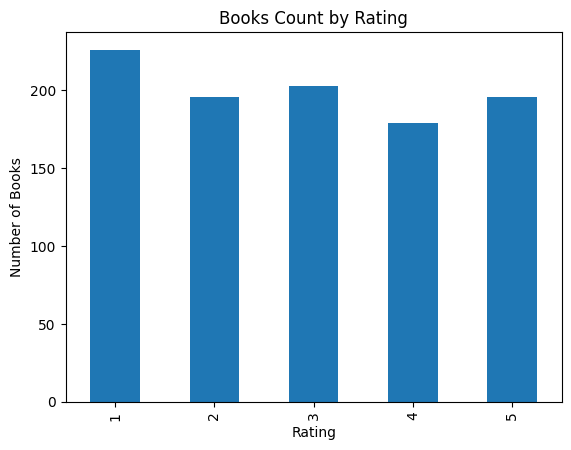

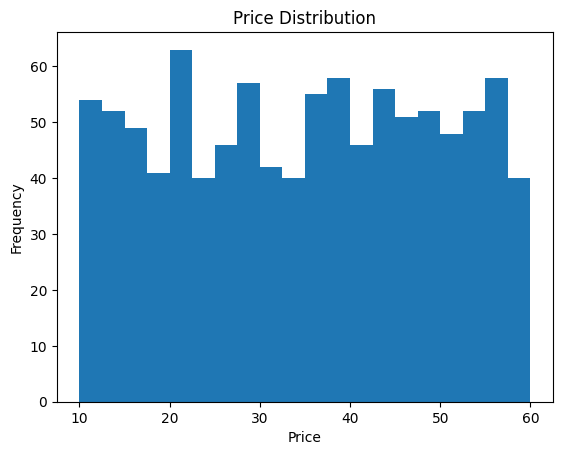

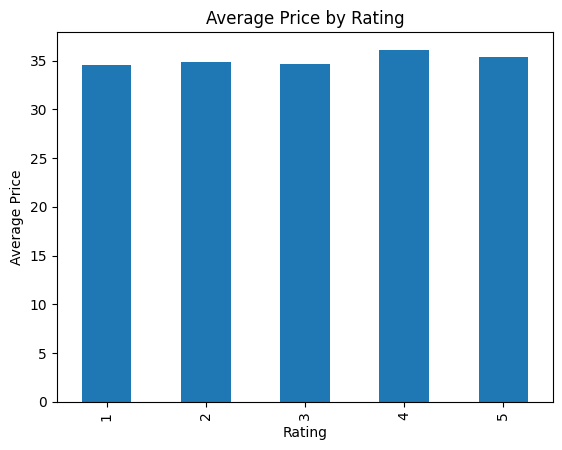

CSV File Saved Successfully!
                                   Title  Price  Rating Availability  \
0                   A Light in the Attic  51.77       3     In stock   
1                     Tipping the Velvet  53.74       1     In stock   
2                             Soumission  50.10       1     In stock   
3                          Sharp Objects  47.82       4     In stock   
4  Sapiens: A Brief History of Humankind  54.23       5     In stock   

                                            Book_URL  
0  https://books.toscrape.com/catalogue/a-light-i...  
1  https://books.toscrape.com/catalogue/tipping-t...  
2  https://books.toscrape.com/catalogue/soumissio...  
3  https://books.toscrape.com/catalogue/sharp-obj...  
4  https://books.toscrape.com/catalogue/sapiens-a...  
(1000, 5)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.DataFrame(books_data)


# Check current data type
print(df["Price"].dtype)

# Remove currency symbol
df["Price"] = df["Price"].str.replace("Â£", "", regex=False)

# Convert into float
df["Price"] = df["Price"].astype(float)

# Verify
print(df["Price"].dtype)
# print(df.head())


#Replacing the Rating strings to numbers
print(df['Rating'].unique())
rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}
df['Rating'] = df["Rating"].map(rating_map)
print(df.head())


#Analysis for Rating
print("Average Rating :",df['Rating'].mean())
print("Highest Rating :",df['Rating'].max())
print("Lowest Rating :",df['Rating'].min())


#Sort by Price
df.sort_values(by="Price", ascending=False)
#Top 5 most Expensive books
df.sort_values(by="Price", ascending=False).head()
#Top 10 most Expensive books
top10 = df.sort_values(by="Price",ascending= False).head(10)
print(top10)


print("Average :",df["Price"].mean())
print("Highest Price :",df["Price"].max())
print("Lowest Price :",df['Price'].min())
print("Count by Rating :",df['Rating'].value_counts())



df.groupby("Rating")['Price'].mean()





#Assignment
print("--------------------Assignment------------------")
print(df.sort_values(by="Price", ascending=False).head())
print(df.sort_values(by="Price").head())
print(df['Rating'].value_counts())
print(df.groupby("Rating")["Price"].mean())
print(df.groupby("Rating")["Price"].max())


#Visualazation
print("---------Visualaizations-----------------------------------------")
#Rating distribution

df['Rating'].value_counts().sort_index().plot(kind="bar")
plt.title("Books Count by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()


#Price Distribution
df['Price'].plot(kind="hist" , bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

#Average Price by Rating
df.groupby("Rating")["Price"].mean().plot(kind="bar")

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price")

plt.show()


#Exporting CSV for 50 Pages
df.to_csv("books_data.csv",index=False)
print("CSV File Saved Successfully!")
